In [ ]:
import os
os.environ["HF_TOKEN"] = "add your Hugging Face token here if needed"

In [11]:
import warnings

# Chặn các cảnh báo tương lai
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
import sys
from pathlib import Path

# Tự động xác định thư mục gốc của dự án
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

# Thêm vào sys.path nếu chưa có
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root added: {PROJECT_ROOT}")

Project root added: C:\Users\ACER\Desktop\comp_stats\GMM_4_missing_data


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import các hàm hỗ trợ từ file mã nguồn nội bộ
from src.airplane_crashes_pipeline import (
    NUMERIC_FEATURES,
    create_visual_report,
    evaluate_imputation,
    run_pipeline,
)

# Thiết lập giao diện biểu đồ
sns.set_theme(style='whitegrid', context='talk')

In [7]:
# Khởi chạy quy trình: Tải dữ liệu -> Tạo dữ liệu thiếu -> Điền khuyết bằng GMM
artifacts = run_pipeline(missing_ratio=0.2, random_state=42, n_components=4)

# Tính toán sai số RMSE
rmse = evaluate_imputation(artifacts.X_complete, artifacts.X_imputed, artifacts.mask)

print('Rows after preprocessing:', artifacts.X_complete.shape[0])
print('Features:', NUMERIC_FEATURES)
print(f'RMSE on masked entries: {rmse:.4f}')

Rows after preprocessing: 5236
Features: ['Aboard', 'Fatalities', 'Ground', 'Year', 'Month', 'Day']
RMSE on masked entries: 20.0597


In [8]:
# Chuyển mảng kết quả thành DataFrame để xem mô tả thống kê
feature_df = pd.DataFrame(artifacts.X_imputed, columns=NUMERIC_FEATURES)
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Aboard,5236.0,26.155080,40.925500,0.000000e+00,5.0,13.000000,28.0,644.000000
Fatalities,5236.0,20.268998,31.847729,-1.678562e+01,4.0,10.000000,23.0,583.000000
Ground,5236.0,1.501183,53.999625,-3.297524e-12,0.0,0.000000,0.0,2750.000000
Year,5236.0,1971.568781,20.219618,1.908000e+03,1960.0,1970.968938,1987.0,2024.607813
Month,5236.0,6.664579,3.166231,1.000000e+00,4.0,6.690353,9.0,12.000000
Day,5236.0,15.803136,7.893187,1.000000e+00,10.0,15.856455,22.0,47.253827


In [13]:
# Tạo các biểu đồ so sánh phân phối và PCA, lưu vào thư mục 'artifacts'
figures = create_visual_report(artifacts, output_dir='artifacts')

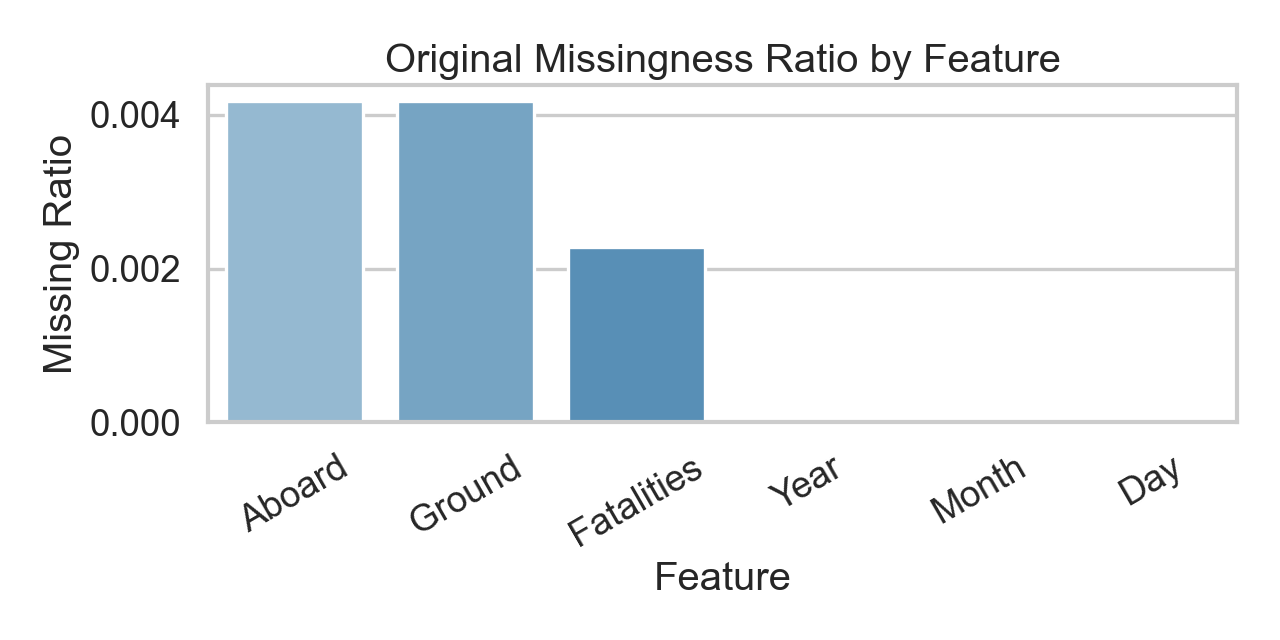

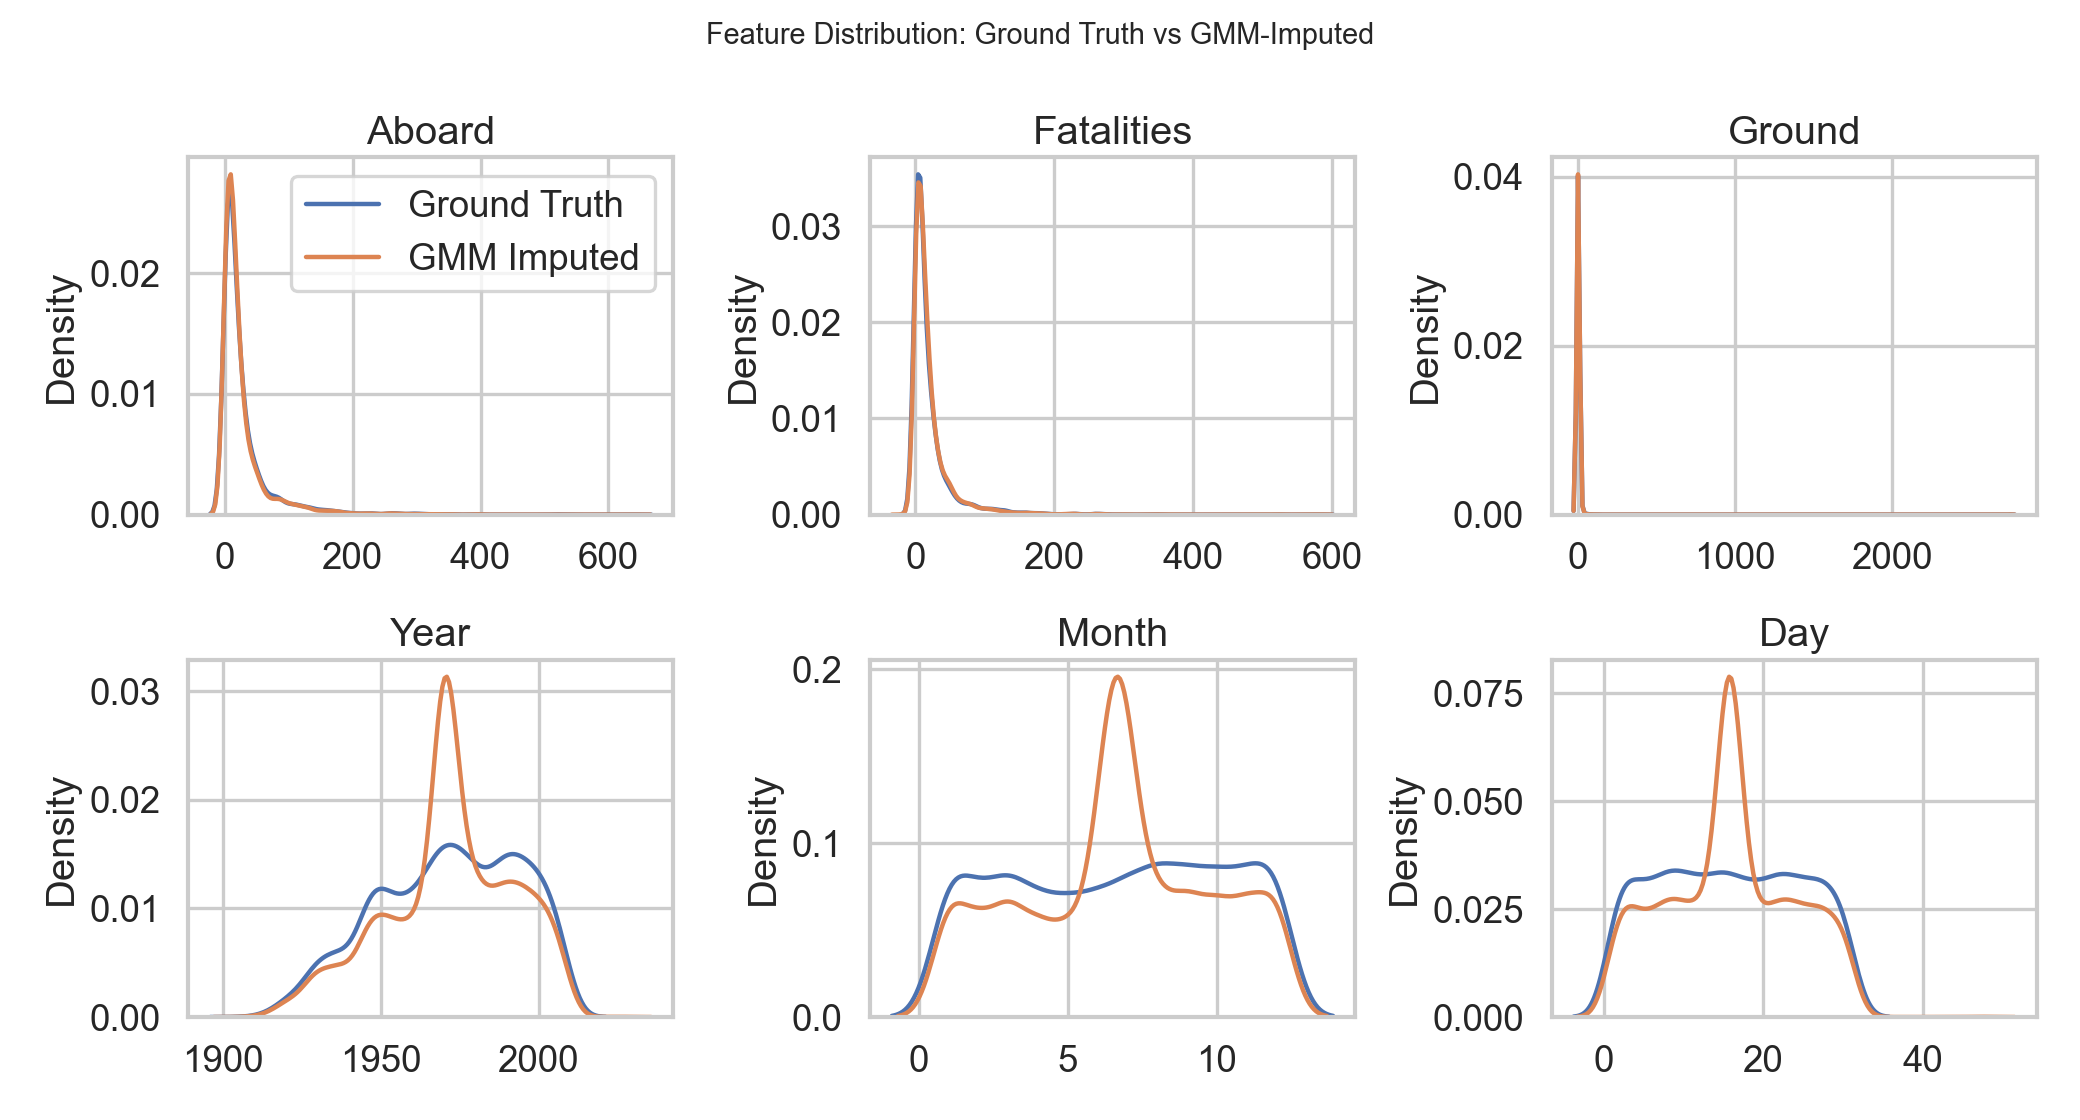

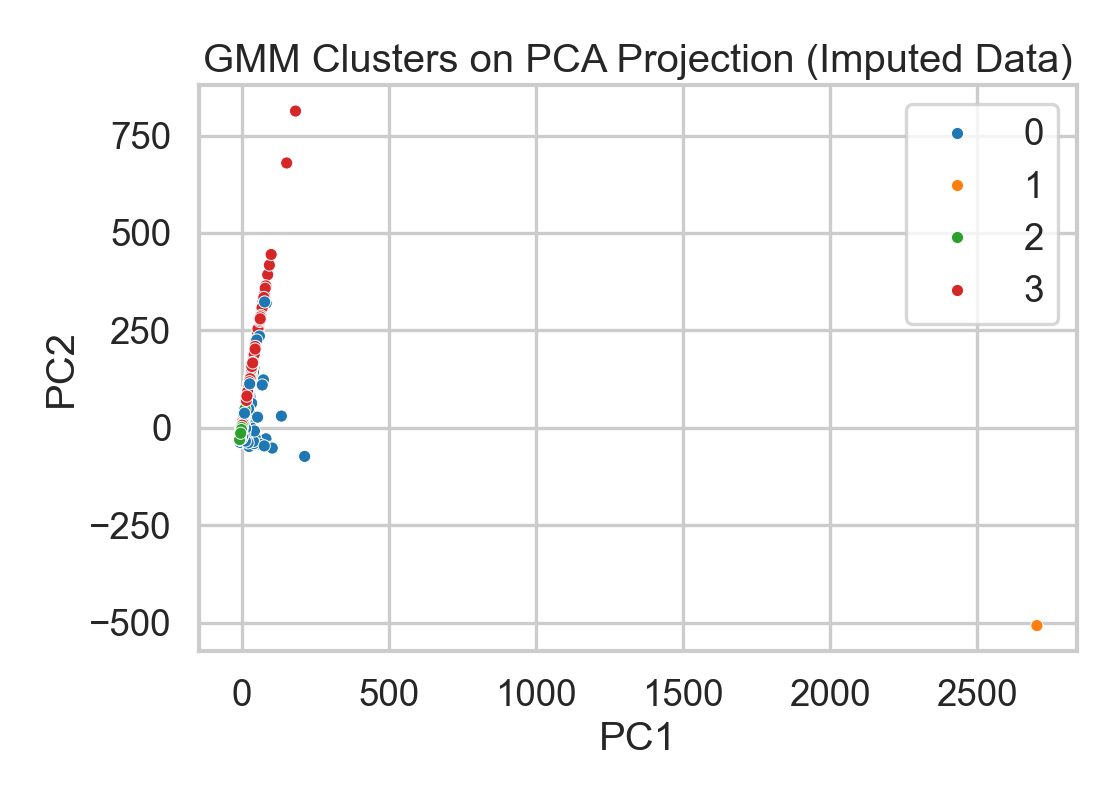

In [14]:
from IPython.display import Image, display

# Quét qua danh sách các đường dẫn file ảnh và hiển thị chúng
for p in figures:
    display(Image(filename=str(p)))